- Python version: 3.11.9
- Numpy: 
- Matplotlib:
- Pandas:
- Skimage:
- OpenCV 2:
- Scipy:
- Torch:
- Tqdm: (To loading bars during the learning process)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from skimage.io import imread

### Useful functions

In [2]:
# Function that displays any number of images 
def imshow(images, gray=False):
    n = len(images)
    plt.figure(figsize=(12,5))
    plt.subplot(1, n, 1)
    for i in range(n):
        plt.subplot(1, n, i + 1)
        if gray: plt.imshow(images[i], cmap='gray')
        else: plt.imshow(images[i])
        plt.axis("off")
    plt.show()

data_dir = "./data/train/"
data_csv = "./data/train_metadata.csv"
df = pd.read_csv(data_csv)

# Function that gets N random images in the dataset
def getRandomImages(N, im_dir=None, norm=False):
    try:
        indices = np.random.randint(0, len(df), size=N)
        if norm:
            if im_dir is None:
                return [imread(data_dir + df.iloc[i, 0]) / 255.0 for i in indices]
            else:
                return [imread(im_dir + df.iloc[i, 0]) / 255.0 for i in indices]
        else:
            if im_dir is None:
                return [imread(data_dir + df.iloc[i, 0]) for i in indices]
            else:
                return [imread(im_dir + df.iloc[i, 0]) for i in indices]
    except FileNotFoundError as _:
        return getRandomImages(N, im_dir)

Example of usage:

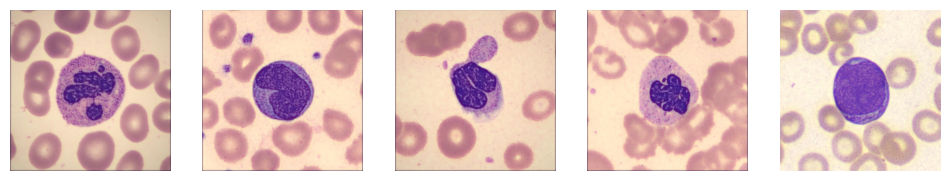

In [3]:
images = getRandomImages(5)
imshow(images)

## Segmentation

In [4]:
import cv2
from scipy import ndimage
from skimage import morphology

In this section, I coded a segmentation for some offline pre-processing. The main idea was to retrieve the purple shape at the center.

### Denoising
Most of the images contained a lot of *speckle noise* as well as acquisition noise so I implemented this function to get the most simplified image I could

In [5]:
def denoise(image):
    median = cv2.medianBlur(image, ksize=9)
    denoised = cv2.edgePreservingFilter(median)
    return denoised

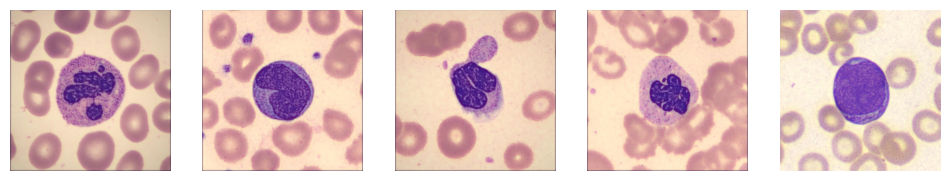

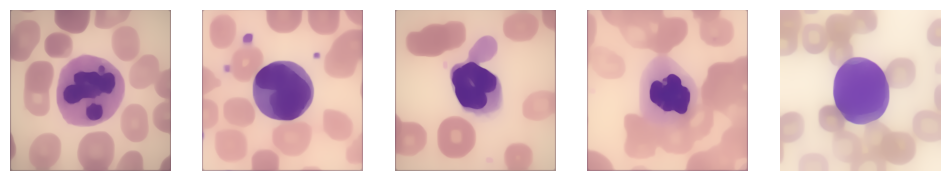

In [6]:
imshow(images)
denoised_images = [denoise(i) for i in images]
imshow(denoised_images)

### Cell extraction
Here I just apply some thresholding on the hue channel in the HSV space, and then run the connected component algorithm to get the purple shape at the center

In [7]:
def get_center(mask):
    mask = (mask * 255).astype(np.uint8)
    _, labels, _, centroids = cv2.connectedComponentsWithStats(mask)
    h, w = mask.shape
    center = np.array([w / 2, h / 2])

    distances = np.linalg.norm(centroids[1:] - center, axis=1)
    if len(distances) == 0: return None

    closest_label = np.argmin(distances) + 1
    middle_mask = (labels == closest_label).astype(np.uint8) * 255
    return middle_mask

def extract_cell(image, low_hue, high_hue):
    hue = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)[:,:,0]
    mask = (hue > low_hue * 255) & (hue < high_hue * 255)
    mask = get_center(mask)
    return mask

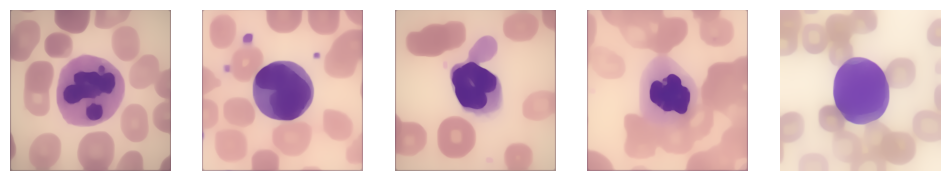

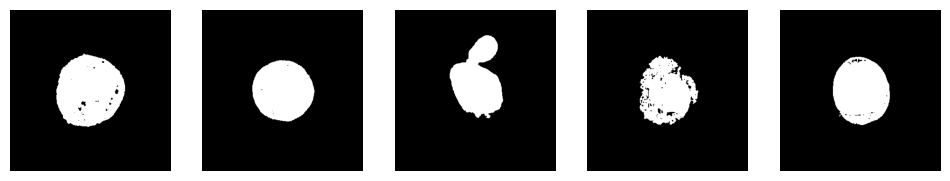

In [8]:
imshow(denoised_images)
extract_cells = [extract_cell(i, 0.5, 0.67) for i in images]
imshow(extract_cells, gray=True)

### Cell cleaning
Now you might notice some holes in the cell. I removed them, and sometimes as some blood cell or another white cell is right next to the one of interest, it is selected by the first connected components algorithm. To try to fix that, I applied some erosion to try to separate the two cells and get the center one.

In [9]:
def clean_cell(mask):
    mask = ndimage.binary_fill_holes(mask)
    mask = morphology.erosion(mask, morphology.disk(10))
    mask = get_center(mask)
    return mask

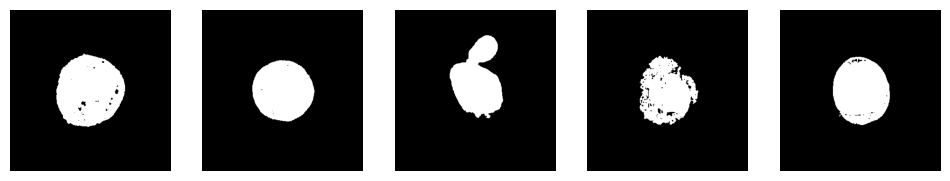

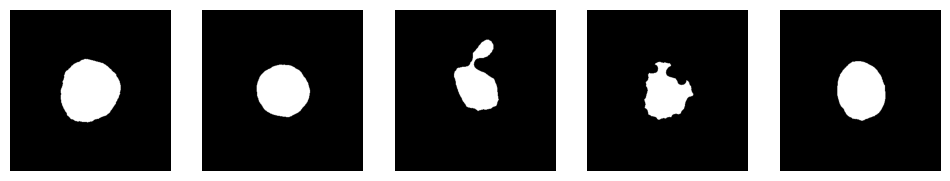

In [10]:
imshow(extract_cells, gray=True)
cleaned_cells = [clean_cell(i) for i in extract_cells]
imshow(cleaned_cells, gray=True)

### Everything together
Now I just put everything together in one function, and apply some dilation to the mask to make sure we have the whole cell 

In [11]:
def segment(image):
    denoised = denoise(image)

    mask = extract_cell(denoised, 0.5, 0.67)
    if mask is None : return None
    mask = clean_cell(mask)
    if mask is None : return None

    mask = morphology.dilation(mask, morphology.disk(25))
    result = image * (mask > 0)[:,:,np.newaxis]
    return result

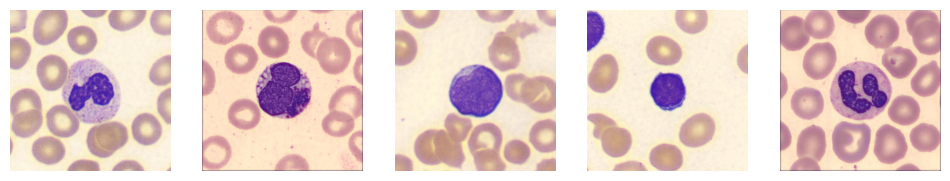

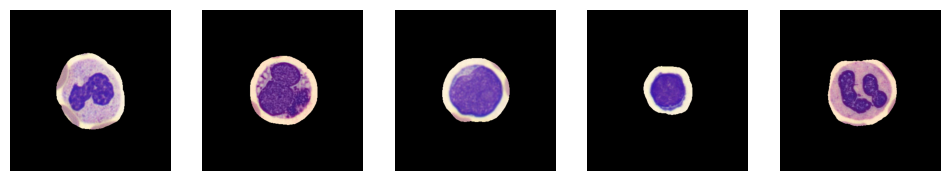

In [12]:
images = getRandomImages(5)
imshow(images)
imshow([segment(i) for i in images])

I did all the segmentation offline, putting everything in `"./data/train_seg"` and `"./data/test_seg"`

## Classification

I have put all the functions here, but on my computer the `num_workers` > 0 in torch's `DataLoader` did not work so I did it on a separate .py

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn.functional as F
from torchvision.io import read_image
from torchvision.transforms import v2
import torch.nn as nn
import os
import multiprocessing
import copy
from tqdm import tqdm

### Useful functions and classes

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("cuda" if torch.cuda.is_available() else "cpu")

cuda


In [15]:
def label_to_int(label):
    labels = {
        "SNE" : 0,  # Segmented neutrophil
        "LY" : 1,   # Lymphocyte
        "MO" : 2,   # Monocyte
        "EO" : 3,   # Eosinophil
        "BA" : 4,   # Basophil
        "VLY" : 5,  # Variant (atypical) lymphocyte
        "BNE" : 6,  # Band-form neutrophil
        "MMY" : 7,  # Metamyelocyte
        "MY" : 8,   # Myelocyte
        "PMY" : 9,  # Promyelocyte
        "BL" : 10,   # Blast cell
        "PC" : 11,   # Plasma cell
        "PLY" : 12   # Prolymphocyte
    }
    return labels[label]

In [16]:
class TrainingDataset(Dataset):
    def __init__(self, folder, df, light_transform, strong_transform, strong_thresh=500):
        self.paths = [
            f
            for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        self.folder = folder
        self.light_transform = light_transform
        self.strong_transform = strong_transform
        self.strong_thresh = strong_thresh
        self.labels = [label_to_int(l) for l in df["label"].values]
        self.label_counts = np.bincount(self.labels)

    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        label = self.labels[idx]
        img = read_image(os.path.join(self.folder, self.paths[idx]))

        if self.label_counts[label] < self.strong_thresh:
            img = self.strong_transform(img)
        else:
            img = self.light_transform(img)
            
        return img, label

In [17]:
class GeM(nn.Module):
    def forward(self, x):
        avg = x.mean(dim=[2,3])
        mx = x.amax(dim=[2,3])
        return torch.cat([avg, mx], dim=1)
    
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.BatchNorm2d(ch),
            nn.LeakyReLU(0.2),
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.BatchNorm2d(ch),
        )
        self.act = nn.LeakyReLU(0.2)
    
    def forward(self, x):
        return self.act(x + self.block(x))

In [18]:
class AddSpeckleNoise:
    def __init__(self, min_std=0.01, max_std=0.15):
        self.min_std = min_std
        self.max_std = max_std

    def __call__(self, img):
        std = torch.empty(1).uniform_(self.min_std, self.max_std).item()
        noise = torch.randn_like(img) * std
        return (img * (1 + noise)).clamp(0, 1)

In [19]:
def removeDeletedLines(df, folder_path):
    return df[df["ID"].apply(lambda x: os.path.exists(os.path.join(folder_path, x)))]

### My CNN Classifier

In [20]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            ResBlock(32),  

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            ResBlock(64), 

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            ResBlock(128), 

            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            ResBlock(256), 

            nn.Conv2d(256, 512, 3, stride=2, padding=1), # 512,8,8
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            ResBlock(512),
        )
        
        self.classifier = nn.Sequential(
            nn.Conv2d(512, 256, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 128, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            GeM(),
            nn.Flatten(1),
            nn.Linear(256, 13)
        )

    def forward(self, input):
        latent = self.encoder(input)
        output = self.classifier(latent)
        return output

### Learning Process

In [27]:
def initLoader(batch_size=32, sampling_beta=0.3):
    multiprocessing.freeze_support()
    multiprocessing.set_start_method('spawn', force=True)

    light_transform = v2.Compose([
        v2.ToDtype(torch.float32, scale=True),
        v2.Resize((256,256)),

        v2.RandomHorizontalFlip(),
        v2.RandomVerticalFlip(),
        v2.RandomApply([v2.RandomRotation(30)], p=0.7),
        
        v2.ColorJitter(
            brightness=(0.75, 1.1)
        ),

        v2.RandomApply([AddSpeckleNoise(max_std=0.25)], p=0.5)
    ])
    strong_transform = v2.Compose([
        v2.ToDtype(torch.float32, scale=True),
        v2.Resize((256,256)),

        v2.RandomHorizontalFlip(),
        v2.RandomVerticalFlip(),
        v2.RandomApply([v2.RandomRotation(30)], p=0.7),
        
        v2.ColorJitter(
            brightness=(0.65, 1.1)
        ),

        v2.RandomApply([AddSpeckleNoise(max_std=0.35)], p=0.7)
    ])

    train_df = pd.read_csv("./data/train_metadata.csv")
    train_df = removeDeletedLines(train_df, "./data/train_seg/")
    dataset = TrainingDataset(
        "./data/train_seg/",
        train_df, 
        light_transform=light_transform,
        strong_transform=strong_transform,
        strong_thresh=100
    )

    labels = dataset.labels
    print("Class counts :")
    print(dataset.label_counts)

    class_weights = 1.0 / (dataset.label_counts ** sampling_beta)
    sample_weights = class_weights[labels]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        dataset, 
        batch_size=batch_size,
        sampler=sampler,
        num_workers=8, 
        persistent_workers=True,
    )

    return train_loader


model = Classifier().to(device)
batch_size = 16
def train():
    print("Start script")

    train_loader = initLoader(batch_size, sampling_beta=0.3)
    print("Loader initialized")
    
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    #criterion = FocalLoss(alpha=alpha.to(device), gamma=1.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    scheduler = torch.optim.lr_scheduler.ExponentialLR(
        optimizer,
        0.95
    )

    df = pd.DataFrame(columns=["loss", "accuracy"])

    best_model = copy.deepcopy(model)
    best_loss = 1e10
    best_epoch = 0

    print("Training starting...")
    for epoch in range(200):
        total_loss = 0
        total_accuracy = 0.0
        for images, labels in tqdm(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            predictions = model(images)
            loss = criterion(predictions, labels)

            predicted_label = torch.argmax(predictions, dim=1)
            errors = (labels == predicted_label)
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            total_accuracy += torch.sum(errors)

        total_accuracy /= len(train_loader) * batch_size
        total_loss /= len(train_loader)
        scheduler.step()
        if (total_loss < best_loss):
            best_loss = total_loss
            best_model = copy.deepcopy(model)
            torch.save(best_model.state_dict(), "autoencoder.pth")
            best_epoch = epoch

        df.loc[len(df)] = {"loss": total_loss, "accuracy": total_accuracy}
        df.to_csv("./data/training_accuracies.csv", index=False)
        print(f"Epoch {epoch}, Loss: {total_loss:.4f}, Accuracy: {total_accuracy}")
    
    torch.save(best_model.state_dict(), "autoencoder.pth")
    print(f"Best model saved with loss {best_loss} (epoch {best_epoch})")

In [28]:
#train()

## Testing

In [29]:
class TestDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.paths = [
            os.path.join(folder_path, f)
            for f in os.listdir(folder_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        path = self.paths[idx]
        label_idx = int(path.split(".")[-2].split("_")[-1])
        img = read_image(path)
        img = self.transform(img) if self.transform else img
        return img, label_idx

In [30]:
def int_to_label(pred):
    labels = {
        0 : "SNE",  # Segmented neutrophil
        1 : "LY",   # Lymphocyte
        2 : "MO",   # Monocyte
        3 : "EO",   # Eosinophil
        4 : "BA",   # Basophil
        5 : "VLY",  # Variant (atypical) lymphocyte
        6 : "BNE",  # Band-form neutrophil
        7 : "MMY",  # Metamyelocyte
        8 : "MY",   # Myelocyte
        9 : "PMY",  # Promyelocyte
        10 : "BL",   # Blast cell
        11 : "PC",   # Plasma cell
        12 : "PLY"   # Prolymphocyte
    }
    return labels[pred]

In [31]:
transform = v2.Compose([
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((256, 256)),
])

test_dataset = TestDataset(
    "./data/test_seg/",
    transform=transform
)
sample_df = pd.read_csv("./data/sample_submission.csv")
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=0)

In [35]:
model.eval()
all_preds = []
all_indices = []
with torch.no_grad():
    for images, label_indices in tqdm(test_loader):
        images = images.to(device)

        predictions = model(images)
        preds = torch.argmax(predictions, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_indices.extend(label_indices)

for i in range(len(all_indices)):
    df_idx = all_indices[i]
    pred = int_to_label(all_preds[i])
    sample_df.iloc[df_idx, 1] = pred

 10%|▉         | 29/300 [00:04<00:41,  6.55it/s]


KeyboardInterrupt: 